# SMS Spam Classification using Machine Learning
This project classifies SMS messages as Spam or Not Spam using Natural Language Processing and Naive Bayes algorithm.

## Install Required Libraries
This step installs all required libraries for data processing, machine learning, and text preprocessing.

In [23]:
import pandas as pd
import numpy as np
import nltk
import string
import pickle
import seaborn as sns
import matplotlib.pyplot as plt


from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Download Stopwords

Stopwords are common words such as "the", "is", "and" which do not contribute much to text classification. These words are removed during text preprocessing.

In [17]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jashshah/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load Dataset

In this step, the SMS Spam dataset is loaded. The dataset contains SMS messages labeled as spam or ham.

In [3]:
df = pd.read_csv("spam.csv", sep='\t', names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Convert Labels into Numerical Values

Machine learning models work with numerical data, so the labels "spam" and "ham" are converted into numerical values (1 for spam and 0 for ham).

In [4]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

## Text Preprocessing

In this step, the text data is cleaned by converting text to lowercase, removing punctuation, and removing stopwords. This helps improve the performance of the model.

In [5]:
def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]
    return ' '.join(words)

df['message'] = df['message'].apply(clean_text)

## Feature Extraction using TF-IDF

TF-IDF (Term Frequency – Inverse Document Frequency) is used to convert text data into numerical feature vectors so that the machine learning model can understand the text data.

In [6]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['message'])
y = df['label']

## Split Dataset into Training and Testing Data

The dataset is divided into training data and testing data. The training data is used to train the model, and the testing data is used to evaluate the model.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train the Naive Bayes Model

In this step, the Naive Bayes algorithm is used to train the spam classification model using the training data.

In [8]:
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Model Prediction

The trained model is used to predict whether the messages in the test dataset are spam or not spam.

In [9]:
y_pred = model.predict(X_test)

## Model Evaluation

The performance of the model is evaluated using accuracy, confusion matrix, and classification report.

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9704035874439462
Confusion Matrix:
 [[966   0]
 [ 33 116]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



## Save the Model

The trained model and TF-IDF vectorizer are saved so that they can be used later without retraining the model.

In [11]:
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))

## Predict New SMS

In this step, a new SMS message is given as input, and the model predicts whether the message is spam or not spam.

In [12]:
def predict_sms(text):
    text = clean_text(text)
    vector = tfidf.transform([text])
    result = model.predict(vector)
    
    if result == 1:
        return "Spam Message"
    else:
        return "Not Spam Message"

# Test the model
predict_sms("Free entry in a lottery! Call now!")

'Spam Message'

## Dataset Information

This step displays the total number of SMS messages in the dataset and the number of spam and ham messages. 
This helps in understanding the dataset distribution.

In [13]:
print("Dataset Shape:", df.shape)
print("\nSpam and Ham Count:\n", df['label'].value_counts())

Dataset Shape: (5572, 2)

Spam and Ham Count:
 label
0    4825
1     747
Name: count, dtype: int64


## Confusion Matrix Visualization

The confusion matrix is visualized using a heatmap. 
It shows the number of correct and incorrect predictions made by the model.

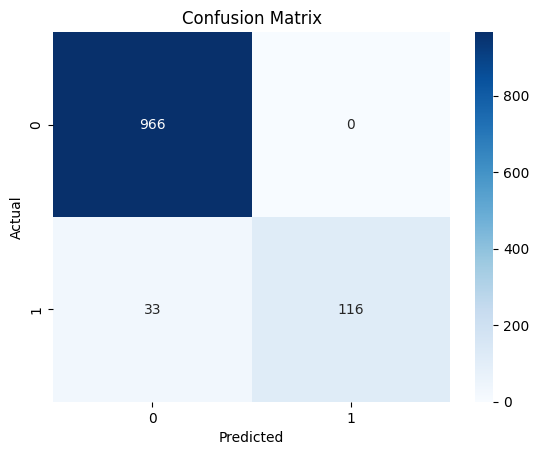

In [24]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Conclusion

The SMS Spam Classification system was successfully developed using Machine Learning.
Text preprocessing and TF-IDF were used for feature extraction, and the Naive Bayes algorithm was used for classification.
The model achieved an accuracy of 97%, which shows that the model performs well in classifying spam and ham messages.
This system can be used to automatically detect spam messages.,